# <i>Exploratory Data Analysis of Job Portal Postings: Insights from TIMESJOBS portal</i>

## importing Modules

In [252]:
import pandas as pd
import numpy as np
import requests
import seaborn as sns
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup
import re

In [194]:
!pip install wordcloud
from wordcloud import WordCloud

Defaulting to user installation because normal site-packages is not writeable


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


## passing url

In [603]:
url="https://www.timesjobs.com/candidate/job-search.html?from=submit&luceneResultSize=1500&postWeek=60&searchType=Home_Search&cboPresFuncArea=35&pDate=Y&sequence=2&startPage=1&hc=CLUSTER_FA"

In [604]:
response=requests.get(url)

## passing the content of the url to web page parser (HTML parser) and retriving data.

In [605]:
soup=BeautifulSoup(response.content)

In [20]:
job_title=[]
posted_on=[]
years_of_experiance=[]
locations=[]
job_function=[]
industry=[]
Specialization=[]
Qualification=[]
Employment_Type=[]
skills=[]
company_names=[]
Industry=[]
Company_Turnover=[]
Company_Size=[]
j=0

for i in soup.find_all("li",class_="clearfix job-bx wht-shd-bx"):
    t=str(i.find("a",class_="posoverlay_srp"))
    if t:
        
        urls=re.findall('href=(".+") ?onclick',t)[0][1:-1]
        try:
            each_url_reaponse=requests.get(urls)
        except:
            pass
        else:
            j+=1
            print(j,end="")
            each_web_bs=BeautifulSoup(each_url_reaponse.content)
            try :
                job_title.append(each_web_bs.find("h1",class_="jd-job-title").text)
            except:
                job_title.append(np.nan)
            try :
                posted_on.append(each_web_bs.find("span",class_="posted-days").text)
            except:
                posted_on.append(np.nan)
            try :
                years_of_experiance.append(re.findall("\w?\w ?to ?\w\w?",each_web_bs.find_all("ul",class_="top-jd-dtl d-flex mt-8")[0].text))
            except:
                years_of_experiance.append(np.nan)
            try :
                locations.append(each_web_bs.find_all("span",class_="job-location-trunicate")[0].text)
            except:
                locations.append(np.nan)
            try :
                job_function.append(each_web_bs.find_all("span",class_="basic-info-dtl")[0].text)
            except:
                job_function.append(np.nan)
            try :
                industry.append(each_web_bs.find_all("span",class_="basic-info-dtl")[1].text)
            except:
                industry.append(np.nan)
            try :
                Specialization.append(each_web_bs.find_all("span",class_="basic-info-dtl")[2].text)
            except:
                Specialization.append(np.nan)
            try :
                temp=each_web_bs.find_all("span",class_="basic-info-dtl")[3].text
                Qualification.append(temp)
            except:
                Qualification.append(np.nan)
            try:
                Employment_Type.append(each_web_bs.find_all("span",class_="mt-4")[0].text)
            except:
                Employment_Type.append(np.nan)
            try :
                company_names.append(each_web_bs.find_all("span",class_="basic-info-dtl")[4].text)
            except:
                company_names.append(np.nan)
            try :
                skills.append([i.text for i in each_web_bs.find_all("span",class_="jd-skill-tag")])
            except:
                skills.append(np.nan)
            try:
                Industry.append(each_web_bs.find_all("span",class_="basic-info-dtl")[6].text)
            except:
                Industry.append(np.nan)
            try:
                Company_Turnover.append(each_web_bs.find_all("span",class_="basic-info-dtl")[7].text)
            except:
                Company_Turnover.append(np.nan)
            try:
                Company_Size.append(each_web_bs.find_all("span",class_="basic-info-dtl")[8].text)
            except:
                Company_Size.append(np.nan)

<>:39: SyntaxWarning: invalid escape sequence '\w'
<>:39: SyntaxWarning: invalid escape sequence '\w'
C:\Users\heman\AppData\Local\Temp\ipykernel_3224\2639983289.py:39: SyntaxWarning: invalid escape sequence '\w'
  years_of_experiance.append(re.findall("\w?\w ?to ?\w\w?",each_web_bs.find_all("ul",class_="top-jd-dtl d-flex mt-8")[0].text))


1234567891011121314151617181920212223242526272829303132333435363738394041424344454647484950515253545556575859606162636465666768697071727374757677787980818283848586878889909192939495969798991001011021031041051061071081091101111121131141151161171181191201211221231241251261271281291301311321331341351361371381391401411421431441451461471481491501511521531541551561571581591601611621631641651661671681691701711721731741751761771781791801811821831841851861871881891901911921931941951961971981992002012022032042052062072082092102112122132142152162172182192202212222232242252262272282292302312322332342352362372382392402412422432442452462472482492502512522532542552562572582592602612622632642652662672682692702712722732742752762772782792802812822832842852862872882892902912922932942952962972982993003013023033043053063073083093103113123133143153163173183193203213223233243253263273283293303313323333343353363373383393403413423433443453463473483493503513523533543553563573583593603613623633643653663673683693

## making the data into the DataFrame using pandas

In [22]:
data={"job_title":job_title,
"posted_on":posted_on,
"years_of_experiance":years_of_experiance,
"locations":locations,
"job_function":job_function,
"industry":industry,
"Specialization":Specialization,
"Qualification":Qualification,
"Employment_Type":Employment_Type,
"skills":skills,
"company_name":company_names,
"Industry":Industry,
"Company_Turnover":Company_Turnover,
"Company_Size":Company_Size}

In [23]:
pd.DataFrame(data)

,job_title,posted_on,years_of_experiance,locations,job_function,industry,Specialization,Qualification,Employment_Type,skills,company_name,Industry,Company_Turnover,Company_Size
0,"\r\n\t\t \r\n\t Software Engineer, Metrics a...","17 Oct, 2025",[2 to 5],Mexico (Mexico),IT Software : Software Products & Services,Internet/Dot com/ISP,Software Engineer,\n\n\r\n Any Graduate\r\n ...,Full Time,"[software development , data structures , data...",Google India Pvt Ltd,"Technology (IT, Telecom, Dot Com etc) (E-comme...",10000 - 10000+ Crores,10001 - 10001+ Employees
1,"\r\n\t\t \r\n\t Business Systems Analyst, SA...","17 Oct, 2025",[5 to 8],Hyderabad/ Secunderabad (Telangana),IT Software : Software Products & Services,Internet/Dot com/ISP,ERP/CRM,\n\n\r\n Any Graduate\r\n ...,Full Time,[sap security implementation grc ruleset manag...,Google India Pvt Ltd,"Technology (IT, Telecom, Dot Com etc) (E-comme...",10000 - 10000+ Crores,10001 - 10001+ Employees
2,"\r\n\t\t \r\n\t Senior Software Engineer, Bi...","17 Oct, 2025",[5 to 8],Seattle (Washington),IT Software : Software Products & Services,Internet/Dot com/ISP,Software Engineer,\n\n\r\n BE/ B.Tech (Engine...,Full Time,"[software development , system design , distri...",Google India Pvt Ltd,"Technology (IT, Telecom, Dot Com etc) (E-comme...",10000 - 10000+ Crores,10001 - 10001+ Employees
3,"\r\n\t\t \r\n\t Software Engineer, Classroom...","17 Oct, 2025",[1 to 4],Mexico (Mexico),IT Software : Software Products & Services,Internet/Dot com/ISP,Software Engineer,\n\n\r\n BE/ B.Tech (Engine...,Full Time,"[full stack development , data structures know...",Google India Pvt Ltd,"Technology (IT, Telecom, Dot Com etc) (E-comme...",10000 - 10000+ Crores,10001 - 10001+ Employees
4,"\r\n\t\t \r\n\t Systems Engineer III, Site R...","17 Oct, 2025",[2 to 5],Bengaluru/ Bangalore (Karnataka),IT Software : Software Products & Services,Internet/Dot com/ISP,Software Engineer,\n\n\r\n Any Graduate\r\n ...,Full Time,"[network administration , system design , soft...",Google India Pvt Ltd,"Technology (IT, Telecom, Dot Com etc) (E-comme...",10000 - 10000+ Crores,10001 - 10001+ Employees
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,"\r\n\t\t \r\n\t Software Engineer, Risk and ...","17 Oct, 2025",[2 to 5],Brazil (Brazil),IT Software : Software Products & Services,Internet/Dot com/ISP,Software Engineer,\n\n\r\n Any Graduate\r\n ...,Full Time,"[software development , risk compliance , full...",Google India Pvt Ltd,"Technology (IT, Telecom, Dot Com etc) (E-comme...",10000 - 10000+ Crores,10001 - 10001+ Employees
1496,\r\n\t\t \r\n\t Senior Camera Firmware Engin...,"17 Oct, 2025",[5 to 8],South Korea (South Korea),IT Software : Software Products & Services,Internet/Dot com/ISP,Software Engineer,\n\n\r\n BE/ B.Tech (Engine...,Full Time,"[c programming , image processing , camera tun...",Google India Pvt Ltd,"Technology (IT, Telecom, Dot Com etc) (E-comme...",10000 - 10000+ Crores,10001 - 10001+ Employees
1497,"\r\n\t\t \r\n\t Software Engineer, Embedded ...","17 Oct, 2025",[2 to 5],Taiwan (Taiwan),IT Software : Software Products & Services,Internet/Dot com/ISP,Software Engineer,\n\n\r\n Any Graduate\r\n ...,Full Time,"[software development , embedded programming ,...",Google India Pvt Ltd,"Technology (IT, Telecom, Dot Com etc) (E-comme...",10000 - 10000+ Crores,10001 - 10001+ Employees
1498,"\r\n\t\t \r\n\t Software Engineer III, Searc...","17 Oct, 2025",[2 to 5],Israel (Israel),IT Software : Software Products & Services,Internet/Dot com/ISP,Software Engineer,\n\n\r\n Any Graduate\r\n ...,Full Time,"[software development , data structures , algo...",Google India Pvt Ltd,"Technology (IT, Telecom, Dot Com etc) (E-comme...",10000 - 10000+ Crores,10001 - 10001+ Employees


In [28]:
df=pd.DataFrame(data)

## making the DataFrame into a csv file

In [96]:
#df.to_csv(r"C:\Users\heman\OneDrive\Desktop\AFTER BTECH\innomatics\EDA Project\extracted_data.csv")

In [609]:
df=pd.read_csv(r"C:\Users\heman\OneDrive\Desktop\AFTER BTECH\innomatics\EDA Project\extracted_data.csv",index_col="Unnamed: 0")

In [610]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1500 entries, 0 to 1499
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_title            1500 non-null   object
 1   posted_on            1500 non-null   object
 2   years_of_experiance  1500 non-null   object
 3   locations            1500 non-null   object
 4   job_function         1500 non-null   object
 5   industry             1500 non-null   object
 6   Specialization       1500 non-null   object
 7   Qualification        1500 non-null   object
 8   Employment_Type      1500 non-null   object
 9   skills               1500 non-null   object
 10  company_name         1500 non-null   object
 11  Industry             1480 non-null   object
 12  Company_Turnover     1387 non-null   object
 13  Company_Size         1387 non-null   object
dtypes: object(14)
memory usage: 175.8+ KB


In [611]:
df.dtypes

job_title              object
posted_on              object
years_of_experiance    object
locations              object
job_function           object
industry               object
Specialization         object
Qualification          object
Employment_Type        object
skills                 object
company_name           object
Industry               object
Company_Turnover       object
Company_Size           object
dtype: object

## Data Cleaning

In [612]:
df["job_title"]=df["job_title"].str.replace("\n","")
df["job_title"]=df["job_title"].str.replace("\r","")
df["job_title"]=df["job_title"].str.replace("\t","")

In [613]:
df["Qualification"]=df["Qualification"].str.replace("\n","")
df["Qualification"]=df["Qualification"].str.replace("\r","")
df["Qualification"]=df["Qualification"].str.replace("\t","")

In [614]:
df["Qualification"]=df["Qualification"].str.strip()

In [615]:
def a(x):
    return re.findall("   \w.+",str(x))
df["Qualification"].apply(a).value_counts()

<>:2: SyntaxWarning: invalid escape sequence '\w'
<>:2: SyntaxWarning: invalid escape sequence '\w'
C:\Users\heman\AppData\Local\Temp\ipykernel_18916\2816634452.py:2: SyntaxWarning: invalid escape sequence '\w'
  return re.findall("   \w.+",str(x))


Qualification
[   BE/ B.Tech (Engineering)]      681
[]                                 610
[   Any Graduate]                  200
[   BBA/ BBM/ BBS]                   6
[   BCA (Computer Application)]      2
[   BA (Arts)]                       1
Name: count, dtype: int64

In [616]:
#df=pd.read_csv(r"C:\Users\heman\OneDrive\Desktop\AFTER BTECH\innomatics\EDA Project\extracted_data1.csv",index_col="Unnamed: 0")

In [617]:
df["Qualification"]=df["Qualification"].apply(lambda x:x.replace("                                                                              ",",  ") if re.findall("                                                                              ",x) else x)
def b(x):
    l=[]
    for i in x.split(","):
        q=i.strip()
        l.append(q[1:-1:].strip())
    return l
df["skills"]=df["skills"].apply(b)

In [618]:
df.isnull().sum()

job_title                0
posted_on                0
years_of_experiance      0
locations                0
job_function             0
industry                 0
Specialization           0
Qualification            0
Employment_Type          0
skills                   0
company_name             0
Industry                20
Company_Turnover       113
Company_Size           113
dtype: int64

In [619]:
df["posted_on"]=pd.to_datetime(df["posted_on"])

## Data manipulation

In [621]:
df["years_of_experiance_from"]=df["years_of_experiance"].apply(lambda x:x[2:4:])
df["years_of_experiance_to"]=df["years_of_experiance"].apply(lambda x:x[7:10:]).apply(lambda x:x.replace("'","") if "'" in x else x).apply(lambda x:x.replace("]","") if "]" in x else x)

In [622]:
df["skills"]=df["skills"].apply(lambda x:x[1:-1])

In [623]:
df["Company_Turnover_Started_From(Crores)"]=df["Company_Turnover"].apply(lambda x:re.findall("(.+) -",str(x))).apply(lambda x:str(x)[2:-2:])
df["Company_Turnover_Ended_To(Crores)"]=df["Company_Turnover"].apply(lambda x:re.findall("- (.+)\+? Crores",str(x))).apply(lambda x:str(x)[2:-2:]).apply(lambda x:x.replace("+","") if "+" in x else x)

<>:2: SyntaxWarning: invalid escape sequence '\+'
<>:2: SyntaxWarning: invalid escape sequence '\+'
C:\Users\heman\AppData\Local\Temp\ipykernel_18916\951449571.py:2: SyntaxWarning: invalid escape sequence '\+'
  df["Company_Turnover_Ended_To(Crores)"]=df["Company_Turnover"].apply(lambda x:re.findall("- (.+)\+? Crores",str(x))).apply(lambda x:str(x)[2:-2:]).apply(lambda x:x.replace("+","") if "+" in x else x)


In [624]:
df["Company_Size_Stared_From"]=df["Company_Size"].apply(lambda x:re.findall("(.+) -",str(x))).apply(lambda x:str(x)[2:-2])
df["Company_Size_Ended_To"]=df["Company_Size"].apply(lambda x:re.findall("- (.+) Employee",str(x))).apply(lambda x:str(x)[2:-2]).apply(lambda x:x.replace("+","") if "+" in x else x )

In [625]:
df.sample(10)

,job_title,posted_on,years_of_experiance,locations,job_function,industry,Specialization,Qualification,Employment_Type,skills,company_name,Industry,Company_Turnover,Company_Size,years_of_experiance_from,years_of_experiance_to,Company_Turnover_Started_From(Crores),Company_Turnover_Ended_To(Crores),Company_Size_Stared_From,Company_Size_Ended_To
1285,"Staff Software Engineer, Machine Learning",2025-10-17,['8 to 11'],Hyderabad/ Secunderabad (Telangana),IT Software : Software Products & Services,Internet/Dot com/ISP,Software Engineer,"ML/ LLM (Law), Any Graduate",Full Time,"[software design, cloud services (gcp), data s...",Google India Pvt Ltd,"Technology (IT, Telecom, Dot Com etc) (E-comme...",10000 - 10000+ Crores,10001 - 10001+ Employees,8,11,10000,10000,10001,10001
213,Tech Lead,2025-10-17,['5 to 8'],Hyderabad/ Secunderabad (Telangana),IT Software : Software Products & Services,"Software Services, Internet/Dot com/ISP",ERP/CRM,Any Graduate,Full Time,"[system integration knowledge, testing and tro...",Tech Mahindra Ltd,"Technology (IT, Telecom, Dot Com etc) (Softwar...",10000 - 10000+ Crores,10001 - 10001+ Employees,5,8,10000,10000,10001,10001
830,Career Opportunities: Software Engineer (4...,2025-10-17,['3 to 5'],Mexico (Mexico),IT Software : Software Products & Services,"Software Services, Internet/Dot com/ISP",Software Engineer,"MCA/ PGDCA, ME/ M.Tech./ MS (Engg/ Sciences),...",Full Time,"[aws technologies, cloud deployment, serverles...",Incedo Inc,"Technology - IT, Telecom, Semiconductors (Othe...",1 - 100 Crores,51 - 200 Employees,3,5,1,100,51,200
1493,"Software Engineering Manager, AI Powered D...",2025-10-17,['8 to 11'],Bengaluru/ Bangalore (Karnataka),IT Software : Software Products & Services,Internet/Dot com/ISP,Software Engineer,"ML/ LLM (Law), Any Graduate",Full Time,"[machine learning, software development, team ...",Google India Pvt Ltd,"Technology (IT, Telecom, Dot Com etc) (E-comme...",10000 - 10000+ Crores,10001 - 10001+ Employees,8,11,10000,10000,10001,10001
541,Career Opportunities: Senior Data Scientis...,2025-10-17,['7 to 9'],Mexico (Mexico),IT Software : Software Products & Services,"Software Services, Internet/Dot com/ISP",Software Engineer,"MCA/ PGDCA, ME/ M.Tech./ MS (Engg/ Sciences),...",Full Time,"[statistical analysis techniques, data wrangli...",Incedo Inc,"Technology - IT, Telecom, Semiconductors (Othe...",1 - 100 Crores,51 - 200 Employees,7,9,1,100,51,200
1069,Career Opportunities: Data Scientist (4550...,2025-10-17,['4 to 6'],Mexico (Mexico),IT Software : Software Products & Services,"Software Services, Internet/Dot com/ISP",Software Engineer,"MCA/ PGDCA, ME/ M.Tech./ MS (Engg/ Sciences),...",Full Time,"[statistical analysis techniques, data wrangli...",Incedo Inc,"Technology - IT, Telecom, Semiconductors (Othe...",1 - 100 Crores,51 - 200 Employees,4,6,1,100,51,200
47,"Cloud Architect, Google Workspace (English)",2025-10-17,['3 to 6'],"Mexico (Mexico), Argentina (Argentina)",IT Software : Software Products & Services,Internet/Dot com/ISP,Project Leader/ Project Manager,"MBA/ PGDM, Any Graduate",Full Time,"[project management expertise, saas/iaas/paas ...",Google India Pvt Ltd,"Technology (IT, Telecom, Dot Com etc) (E-comme...",10000 - 10000+ Crores,10001 - 10001+ Employees,3,6,10000,10000,10001,10001
364,Software Engineer,2025-10-17,['3 to 7'],"Delhi (Delhi), Navi Mumbai (Maharashtra)",IT Software : Software Products & Services,"Banking, Financial Services/Stockbroking",Software Engineer,"ME/ M.Tech./ MS (Engg/ Sciences), Any Graduate",Full Time,"[microservices architecture, aws technologies,...",Morningstar India Pvt Ltd,"Banking, Financial Services & Insurance (Mutua...",1 - 100 Crores,51 - 200 Employees,3,7,1,100,51,200
283,Principal Site Reliability Developer,2025-10-17,['10 to 13'],"Bengaluru/ Bangalore (Karnataka), Pune (Mahara...",IT Software : Software Products & Services,"Software Services, IT-Software",Software Engineer,BE/ B.Tech (Engineering),Full Time,"[cloud services, linux software

In [626]:
df.replace("",np.nan,inplace=True)

In [627]:
df.isnull().sum()

job_title                                  0
posted_on                                  0
years_of_experiance                        0
locations                                  0
job_function                               0
industry                                   0
Specialization                             0
Qualification                              0
Employment_Type                            0
skills                                     0
company_name                               0
Industry                                  20
Company_Turnover                         113
Company_Size                             113
years_of_experiance_from                   0
years_of_experiance_to                     0
Company_Turnover_Started_From(Crores)    113
Company_Turnover_Ended_To(Crores)        113
Company_Size_Stared_From                 113
Company_Size_Ended_To                    113
dtype: int64

In [628]:
df["skills"]=df["skills"].astype("str")

In [629]:
df=df.drop_duplicates()

In [630]:
df.isna().sum()

job_title                                  0
posted_on                                  0
years_of_experiance                        0
locations                                  0
job_function                               0
industry                                   0
Specialization                             0
Qualification                              0
Employment_Type                            0
skills                                     0
company_name                               0
Industry                                  20
Company_Turnover                         113
Company_Size                             113
years_of_experiance_from                   0
years_of_experiance_to                     0
Company_Turnover_Started_From(Crores)    113
Company_Turnover_Ended_To(Crores)        113
Company_Size_Stared_From                 113
Company_Size_Ended_To                    113
dtype: int64

In [631]:
df.dropna(subset="Industry",inplace=True)

In [632]:
df.isna().sum()

job_title                                 0
posted_on                                 0
years_of_experiance                       0
locations                                 0
job_function                              0
industry                                  0
Specialization                            0
Qualification                             0
Employment_Type                           0
skills                                    0
company_name                              0
Industry                                  0
Company_Turnover                         93
Company_Size                             93
years_of_experiance_from                  0
years_of_experiance_to                    0
Company_Turnover_Started_From(Crores)    93
Company_Turnover_Ended_To(Crores)        93
Company_Size_Stared_From                 93
Company_Size_Ended_To                    93
dtype: int64

In [633]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1474 entries, 0 to 1499
Data columns (total 20 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   job_title                              1474 non-null   object        
 1   posted_on                              1474 non-null   datetime64[ns]
 2   years_of_experiance                    1474 non-null   object        
 3   locations                              1474 non-null   object        
 4   job_function                           1474 non-null   object        
 5   industry                               1474 non-null   object        
 6   Specialization                         1474 non-null   object        
 7   Qualification                          1474 non-null   object        
 8   Employment_Type                        1474 non-null   object        
 9   skills                                 1474 non-null   object       

In [634]:
#df.replace("",np.nan,inplace=True)

In [635]:
df["years_of_experiance_from"]=df["years_of_experiance_from"].astype("float")
df["years_of_experiance_to"]=df["years_of_experiance_to"].astype("float")
df["Company_Turnover_Started_From(Crores)"]=df["Company_Turnover_Started_From(Crores)"].astype("float")
df["Company_Turnover_Ended_To(Crores)"]=df["Company_Turnover_Ended_To(Crores)"].astype("float")
df["Company_Size_Stared_From"]=df["Company_Size_Stared_From"].astype("float")
df["Company_Size_Ended_To"]=df["Company_Size_Ended_To"].astype("float")

In [636]:
pd.DataFrame( df.groupby("company_name")["Company_Turnover_Started_From(Crores)"].mean())

,Company_Turnover_Started_From(Crores)
company_name,
Binance,1.0
Bombardier Inc.,NaN
Cargill India Pvt. Ltd.,10000.0
Gainwell Technologies,NaN
Goldman Sachs Services Pvt Ltd,10000.0
...,...
upl limited,NaN
vegapay,NaN
volvo group india pvt ltd,NaN


In [637]:
df.dropna(subset="Industry",inplace=True)
df.dropna(subset="Company_Turnover_Started_From(Crores)",inplace=True)

In [638]:
len(df["Qualification"].value_counts())

31

In [639]:
df.isna().sum()

job_title                                0
posted_on                                0
years_of_experiance                      0
locations                                0
job_function                             0
industry                                 0
Specialization                           0
Qualification                            0
Employment_Type                          0
skills                                   0
company_name                             0
Industry                                 0
Company_Turnover                         0
Company_Size                             0
years_of_experiance_from                 0
years_of_experiance_to                   0
Company_Turnover_Started_From(Crores)    0
Company_Turnover_Ended_To(Crores)        0
Company_Size_Stared_From                 0
Company_Size_Ended_To                    0
dtype: int64

In [640]:
df.describe()

,posted_on,years_of_experiance_from,years_of_experiance_to,Company_Turnover_Started_From(Crores),Company_Turnover_Ended_To(Crores),Company_Size_Stared_From,Company_Size_Ended_To
count,1381,1381.000000,1381.000000,1381.000000,1381.000000,1381.000000,1381.000000
mean,2025-10-17 00:00:00,5.220130,7.700941,3648.036206,3813.396090,3685.902245,3932.915279
min,2025-10-17 00:00:00,0.000000,1.000000,1.000000,100.000000,1.000000,10.000000
25%,2025-10-17 00:00:00,3.000000,5.000000,1.000000,100.000000,51.000000,200.000000
50%,2025-10-17 00:00:00,5.000000,8.000000,1.000000,100.000000,51.000000,200.000000
75%,2025-10-17 00:00:00,7.000000,10.000000,10000.000000,10000.000000,10001.000000,10001.000000
max,2025-10-17 00:00:00,15.000000,18.000000,10000.000000,10000.000000,10001.000000,10001.000000
std,NaN,2.747737,2.814235,4760.657808,4782.072664,4717.754218,4737.394501


In [641]:
df.describe(include="object" )

,job_title,years_of_experiance,locations,job_function,industry,Specialization,Qualification,Employment_Type,skills,company_name,Industry,Company_Turnover,Company_Size
count,1381,1381,1381,1381,1381,1381,1381,1381,1381,1381,1381,1381,1381
unique,910,52,88,1,18,11,31,1,1345,33,20,6,7
top,Senior Software Engineer,['7 to 9'],Mexico (Mexico),IT Software : Software Products & Services,"Software Services, Internet/Dot com/ISP",Software Engineer,"MCA/ PGDCA, ME/ M.Tech./ MS (Engg/ Sciences),...",Full Time,"['spring framework', 'hibernate framework', 's...",Incedo Inc,"Technology - IT, Telecom, Semiconductors (Othe...",1 - 100 Crores,51 - 200 Employees
freq,20,192,794,1381,886,1018,601,1381,3,776,784,838,795


# Univariate Analysis

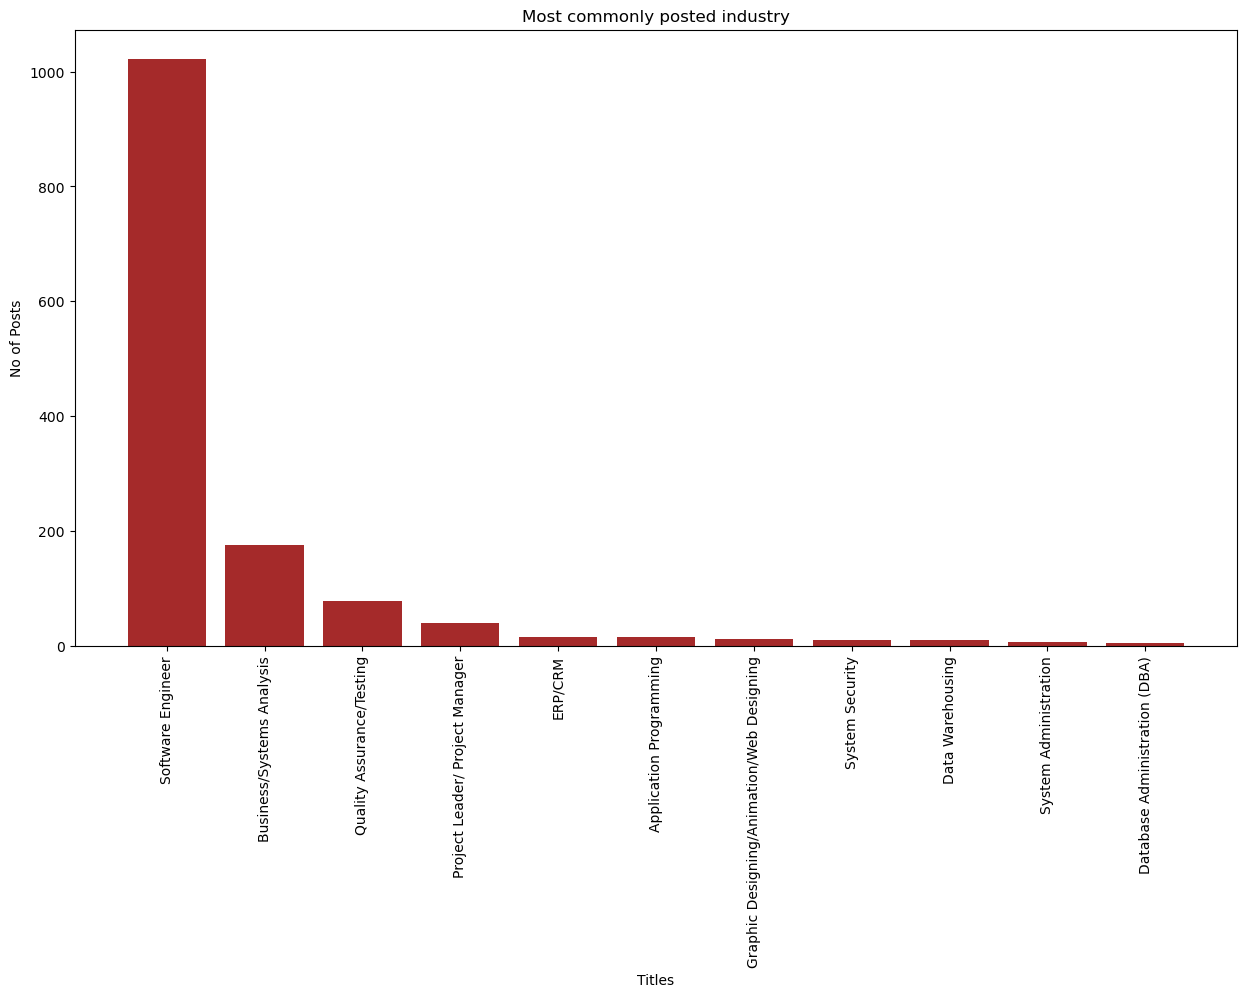

In [595]:
#Most commonly posted titles
temp=df["Specialization"].value_counts()
temp=temp[temp>2]
plt.figure(figsize=(15,8))
plt.bar(temp.index,temp.values,color="brown")
plt.xticks(rotation=90)
plt.xlabel("Titles")
plt.ylabel("No of Posts")
plt.title("Most commonly posted industry")
plt.show()


Text(0.5, 1.0, 'highest number of job postings by Locations')

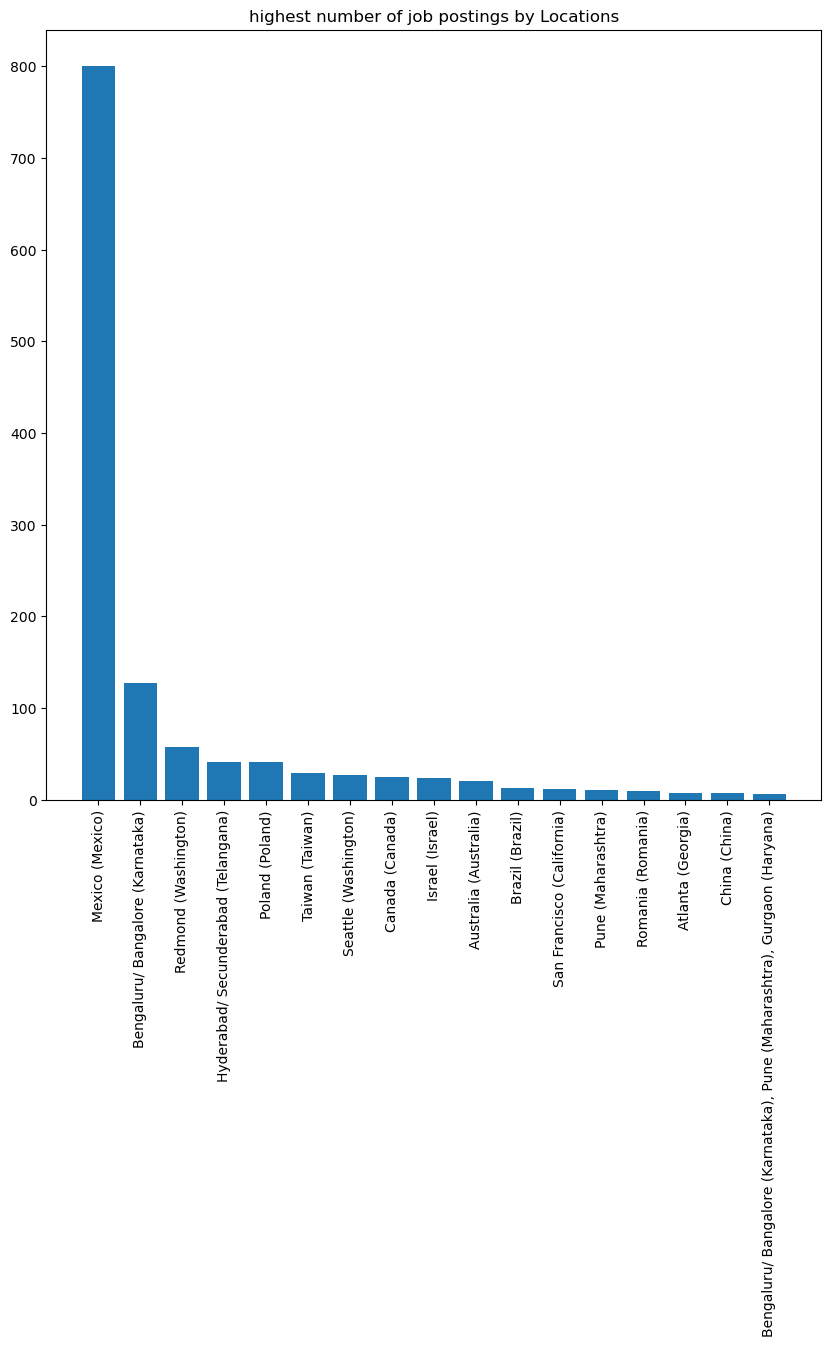

In [596]:
#Which locations have the highest number of job postings?
plt.figure(figsize=(10,10))
temp=df["locations"].value_counts()
temp=temp[temp>5]
plt.bar(temp.index,temp.values)
plt.xticks(rotation=90)
plt.title("highest number of job postings by Locations")

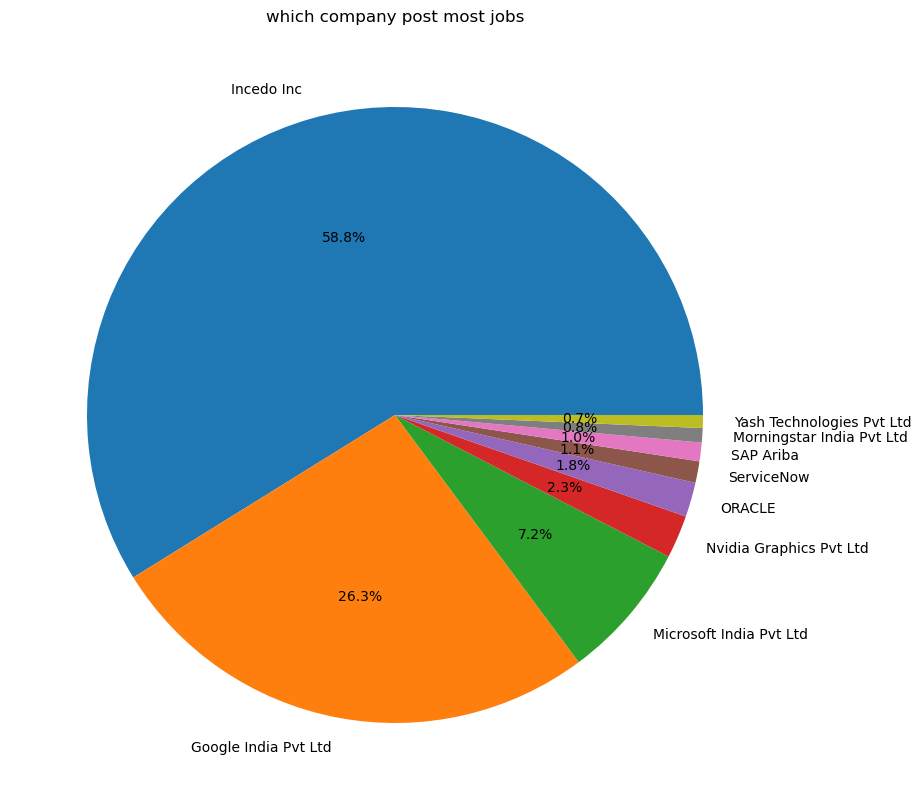

In [597]:
temp=df["company_name"].value_counts()
temp=temp[temp>8]
plt.figure(figsize=(10,10))
plt.pie(temp.values,labels=temp.index,autopct="%1.1f%%")
plt.title("which company post most jobs")
plt.show()

In [598]:
df["job_function"].value_counts()

job_function
IT Software : Software Products & Services    1387
Name: count, dtype: int64

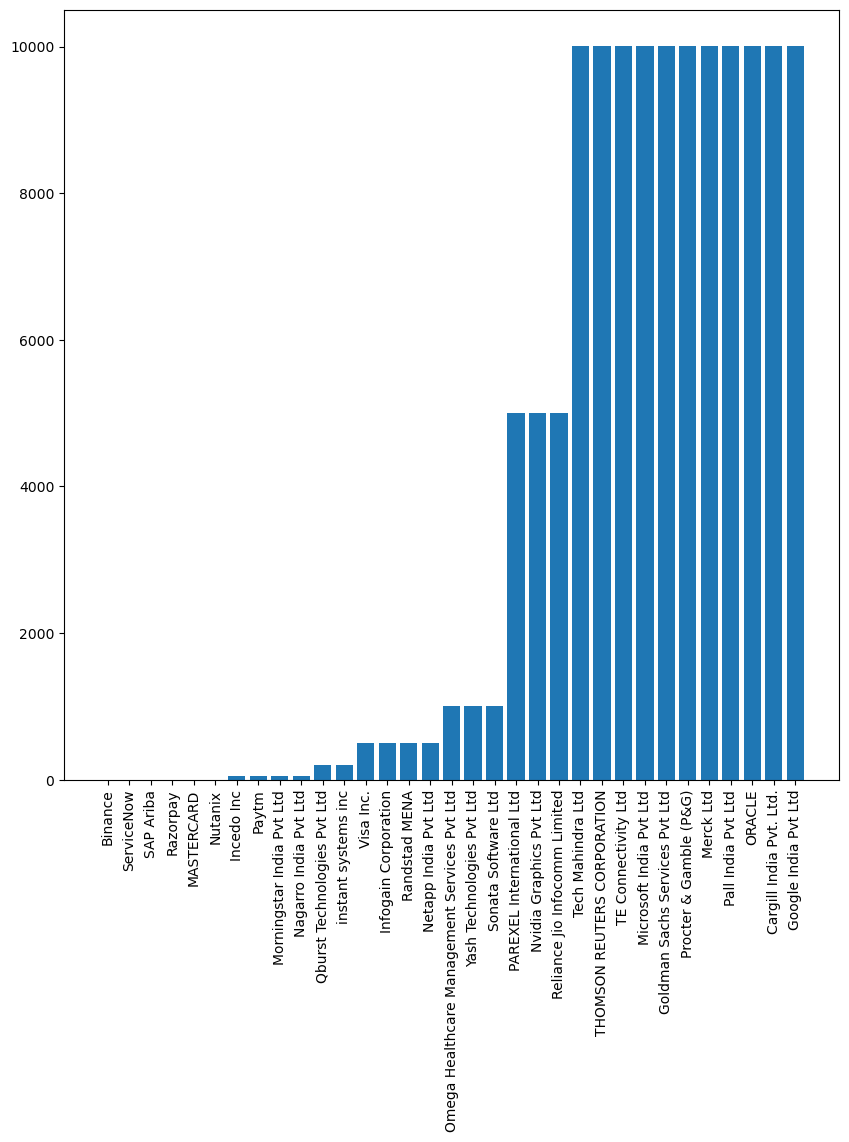

In [599]:
temp=df.groupby("company_name")["Company_Size_Stared_From"].median().sort_values()
#temp=temp[temp>8]
plt.figure(figsize=(10,10))
plt.bar(temp.index,temp.values)
plt.xticks(rotation=90)
plt.title("")
plt.show()

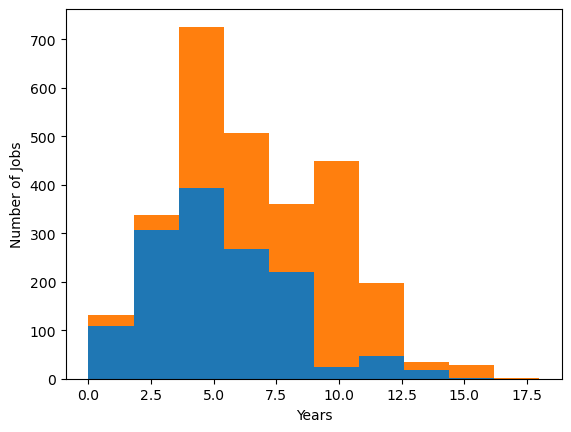

In [600]:
## years of experiance required
plt.hist(df[["years_of_experiance_from","years_of_experiance_to"]],stacked=True)
plt.xlabel("Years")
plt.ylabel("Number of Jobs")
plt.show()

<Axes: ylabel='Count'>

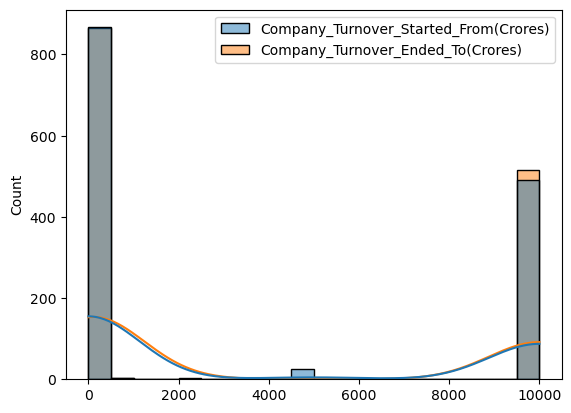

In [601]:
#What is the range of company turnover in crores?
sns.histplot(df[["Company_Turnover_Started_From(Crores)","Company_Turnover_Ended_To(Crores)"]],kde=True,bins=20)

# multivariate analysis

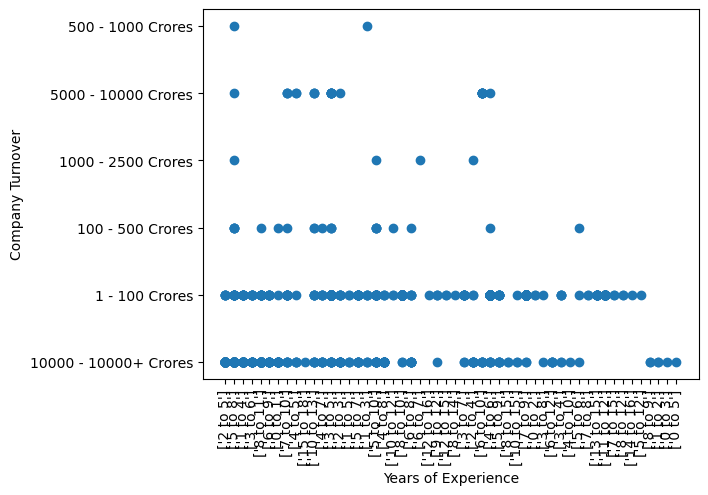

In [602]:
import matplotlib.pyplot as plt
plt.scatter(df['years_of_experiance'], df['Company_Turnover'])
plt.xticks(rotation=90)
plt.xlabel('Years of Experience')
plt.ylabel('Company Turnover')
plt.show()


<Figure size 1000x1000 with 0 Axes>

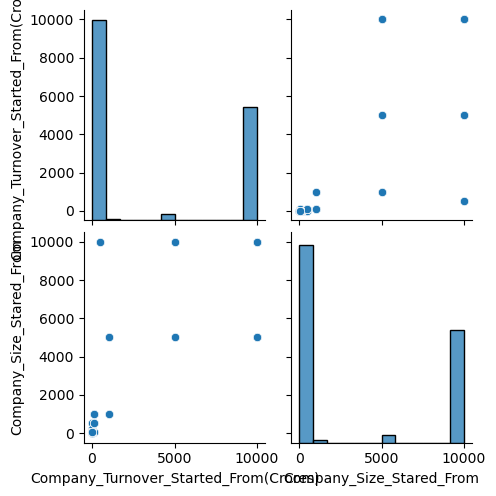

In [554]:
import seaborn as sns
plt.figure(figsize=(10,10))
sns.pairplot(df[['years_of_experiance', 'Company_Turnover_Started_From(Crores)', 'Company_Size_Stared_From']])


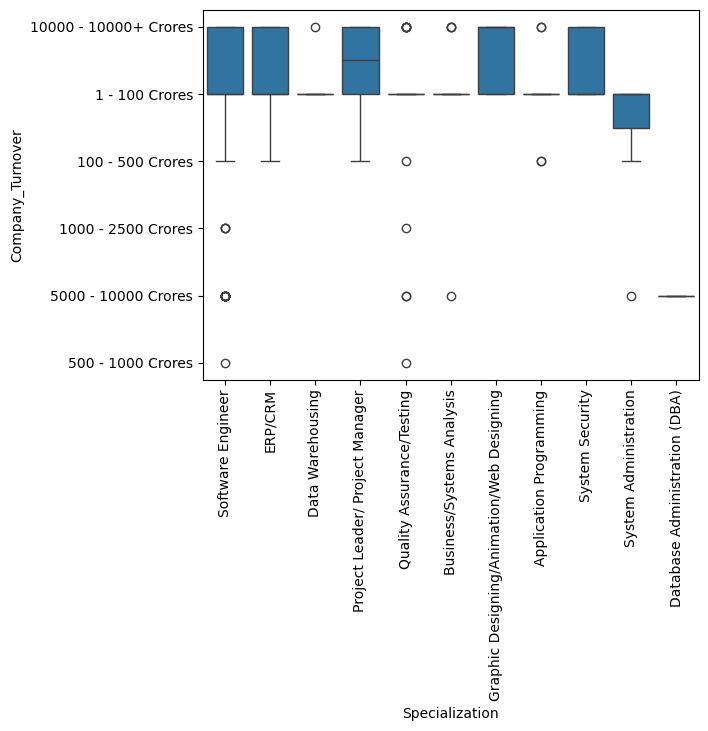

In [558]:
sns.boxplot(x='Specialization', y='Company_Turnover', data=df)
plt.xticks(rotation=90)
plt.show()

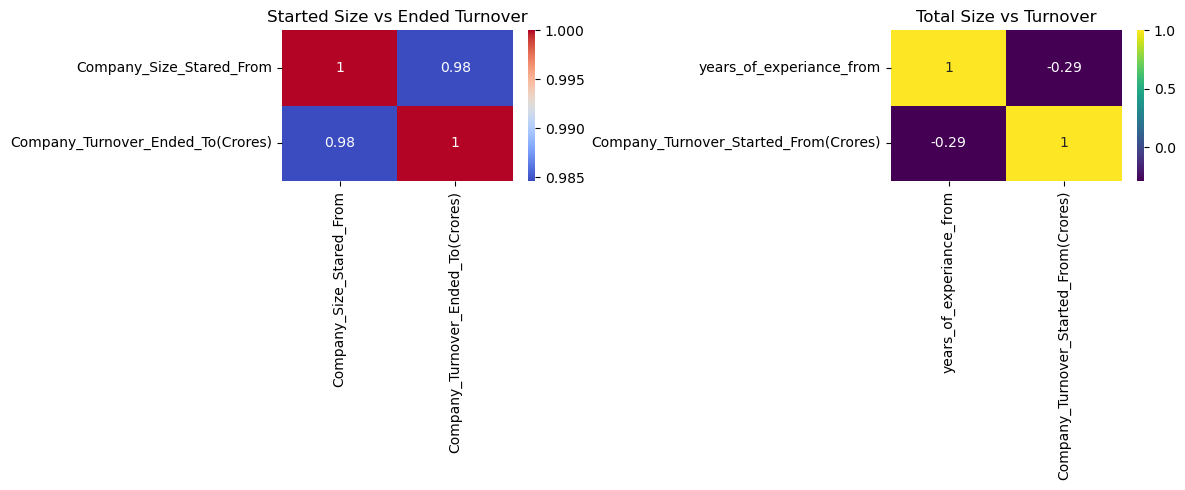

In [549]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(df[['Company_Size_Stared_From','Company_Turnover_Ended_To(Crores)']].corr(), annot=True, cmap='coolwarm', ax=axes[0])
axes[0].set_title("Started Size vs Ended Turnover")

sns.heatmap(df[['years_of_experiance_from','Company_Turnover_Started_From(Crores)']].corr(), annot=True, cmap='viridis', ax=axes[1])
axes[1].set_title("experience vs Turnover")

plt.tight_layout()
plt.show()


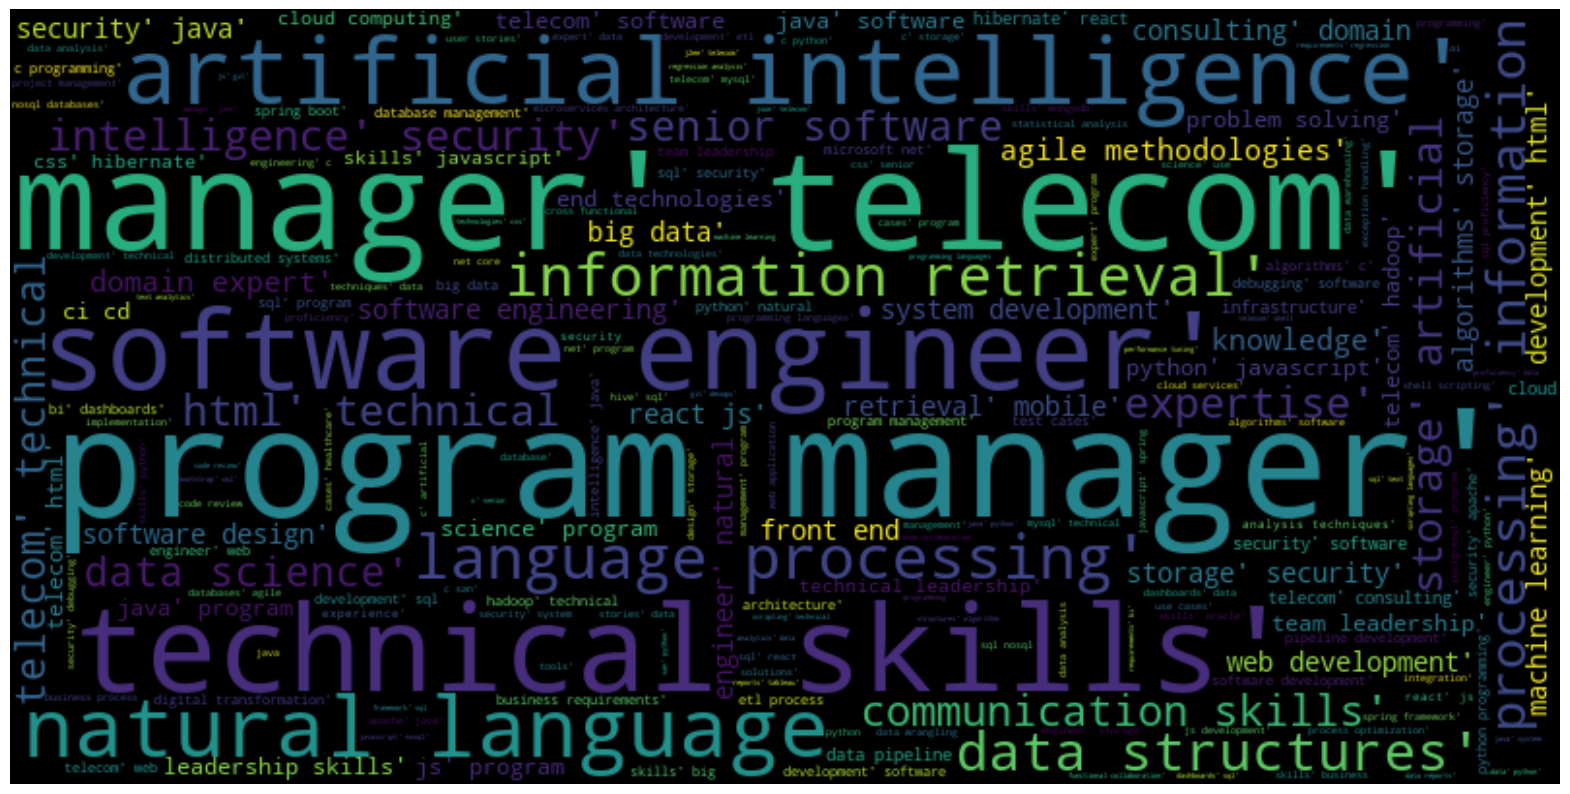

In [503]:
skills_text = ' '.join(df['skills'].dropna().astype(str))
plt.figure(figsize=(20,20))
wordcloud = WordCloud(width=800, height=400).generate(skills_text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [43]:
titles=[]
company_names=[]
posted_on=[]
skills=[]
locations=[]
for i in soup.find_all("li",class_="clearfix job-bx wht-shd-bx"):
    t=i
    #print(t)
    title=t.find("h2",class_="heading-trun")
    #print(title.text)
    if title:
        titles.append(title.text)
    else:
        titles.append(np.nan)
    company_name=t.find("h3",class_="joblist-comp-name")
    if company_name:
        company_names.append(company_name.text)
    else:
        company_names.append(np.nan)
    posted_=t.find("span",class_="sim-posted")
    if posted_:
        posted_on.append(posted_.text)
    else:
        posted_on.append(np.nan)
    skill=t.find("div",class_="more-skills-sections").text
    if skill:
        skills.append(skill)
    else:
        skill.append(np.nan)
    location=t.find("li",class_="srp-zindex location-tru")
    if location:
        locations.append(location.text)
    else:
        locations.append(np.nan)

In [8]:
titles

['\n\r\n      Lilly Hyderabad  Tech Delivery PMO ',
 '\n\r\n      HPC Sr. Product Manager ',
 '\n\r\n      Software Senior Principal Engineer ',
 '\n\r\n      Software Principal Engineer ',
 '\n\r\n      Senior Principal Software Engineer  Email Infrastructure - Powershell Automation,DMARC ',
 '\n\r\n      Software Principal Engineer ',
 '\n\r\n      Software Principal Engineer(C,C  ,Linux,Kernel, Device driver, Fibre channel, Storage) ',
 '\n\r\n      Software Senior Engineer  - Java, Angular, MongoDB and Oracle DB ',
 '\n\r\n      Software Senior Principal Engineer ',
 '\n\r\n      C,Kernel-Software Principal Engineer ',
 '\n\r\n      Senior Data Engineer - IT ',
 '\n\r\n      Full Stack Developer  SDET ',
 '\n\r\n      Performance Senior Engineer ',
 '\n\r\n      Performance Senior Engineer ',
 '\n\r\n      Performance Senior Engineer ',
 '\n\r\n      Software Principal Engineer ',
 '\n\r\n      Full Stack Data Architect & MCP Security Architect ',
 '\n\r\n      Software Principal E

In [9]:
titles

['\n\r\n      Lilly Hyderabad  Tech Delivery PMO ',
 '\n\r\n      HPC Sr. Product Manager ',
 '\n\r\n      Software Senior Principal Engineer ',
 '\n\r\n      Software Principal Engineer ',
 '\n\r\n      Senior Principal Software Engineer  Email Infrastructure - Powershell Automation,DMARC ',
 '\n\r\n      Software Principal Engineer ',
 '\n\r\n      Software Principal Engineer(C,C  ,Linux,Kernel, Device driver, Fibre channel, Storage) ',
 '\n\r\n      Software Senior Engineer  - Java, Angular, MongoDB and Oracle DB ',
 '\n\r\n      Software Senior Principal Engineer ',
 '\n\r\n      C,Kernel-Software Principal Engineer ',
 '\n\r\n      Senior Data Engineer - IT ',
 '\n\r\n      Full Stack Developer  SDET ',
 '\n\r\n      Performance Senior Engineer ',
 '\n\r\n      Performance Senior Engineer ',
 '\n\r\n      Performance Senior Engineer ',
 '\n\r\n      Software Principal Engineer ',
 '\n\r\n      Full Stack Data Architect & MCP Security Architect ',
 '\n\r\n      Software Principal E

In [10]:
posted_on

['\nPosted today\n',
 '\nPosted today\n',
 '\nPosted today\n',
 '\nPosted today\n',
 '\nPosted today\n',
 '\nPosted today\n',
 '\nPosted today\n',
 '\nPosted today\n',
 '\nPosted today\n',
 '\nPosted today\n',
 '\nPosted today\n',
 '\nPosted today\n',
 '\nPosted today\n',
 '\nPosted today\n',
 '\nPosted today\n',
 '\nPosted today\n',
 '\nPosted today\n',
 '\nPosted today\n',
 '\nPosted today\n',
 '\nPosted today\n',
 '\nPosted today\n',
 '\nPosted today\n',
 '\nPosted today\n',
 '\nPosted today\n',
 '\nPosted today\n',
 '\nPosted today\n',
 '\nPosted today\n',
 '\nPosted today\n',
 '\nPosted today\n',
 '\nPosted today\n',
 '\nPosted today\n',
 '\nPosted today\n',
 '\nPosted today\n',
 '\nPosted today\n',
 '\nPosted today\n',
 '\nPosted today\n',
 '\nPosted today\n',
 '\nPosted today\n',
 '\nPosted today\n',
 '\nPosted today\n',
 '\nPosted today\n',
 '\nPosted today\n',
 '\nPosted today\n',
 '\nPosted today\n',
 '\nPosted today\n',
 '\nPosted today\n',
 '\nPosted today\n',
 '\nPosted to

In [11]:
skills

['\n\r\n   \t\t\t\t\tproject management\r\n   \t\t\t\t\n\r\n   \t\t\t\t\tstakeholder management\r\n   \t\t\t\t\n\r\n   \t\t\t\t\trisk management\r\n   \t\t\t\t\n\r\n   \t\t\t\t\tprocess optimization\r\n   \t\t\t\t\n\r\n   \t\t\t\t\tcommunication skills\r\n   \t\t\t\t\n\r\n   \t\t\t\t\tprogram management\r\n   \t\t\t\t\n\r\n   \t\t\t\t\tpmp\r\n   \t\t\t\t\n\r\n   \t\t\t\t\tpmo\r\n   \t\t\t\t\n\r\n   \t\t\t\t\tproject manager\r\n   \t\t\t\t\n\r\n   \t\t\t\t\tagile project management\r\n   \t\t\t\t\n\r\n   \t\t\t\t\tproject management office\r\n   \t\t\t\t\n',
 '\n\r\n   \t\t\t\t\thigh performance computing\r\n   \t\t\t\t\n\r\n   \t\t\t\t\tproduct development management\r\n   \t\t\t\t\n\r\n   \t\t\t\t\tcustomer engagement techniques\r\n   \t\t\t\t\n\r\n   \t\t\t\t\tagile methodologies implementation\r\n   \t\t\t\t\n\r\n   \t\t\t\t\ttechnical requirements analysis\r\n   \t\t\t\t\n\r\n   \t\t\t\t\tresource allocation\r\n   \t\t\t\t\n\r\n   \t\t\t\t\tproject manager\r\n   \t\t\t\t\n\r\n   \t

In [12]:
locations

['\n\r\n              \r\n              Hyderabad/Secunderabad\r\n              \r\n              \r\n               \r\n              ',
 '\n\r\n              \r\n              Germany\r\n              \r\n              \r\n               \r\n              ',
 '\n\r\n              \r\n              Bengaluru / Bangalore\r\n              \r\n              \r\n               \r\n              ',
 '\n\r\n              \r\n              Bengaluru / Bangalore\r\n              \r\n              \r\n               \r\n              ',
 '\n\r\n              \r\n              Bengaluru / Bangalore\r\n              \r\n              \r\n               \r\n              ',
 '\n\r\n              \r\n              Bengaluru / Bangalore\r\n              \r\n              \r\n               \r\n              ',
 '\n\r\n              \r\n              Bengaluru / Bangalore\r\n              \r\n              \r\n               \r\n              ',
 '\n\r\n              \r\n              Bengaluru / Ba